In [32]:
NAME = "Jeevadharan G"
ROLL_NO = "24BAD046"

EXPERIMENT_NAME = "Implementation of Convolutional Neural Networks (CNNs) for Image Classification"


print("EXPERIMENT NO: 3")
print(EXPERIMENT_NAME)
print("==============================================")
print(f" Name     : {NAME}")
print(f" Roll No. : {ROLL_NO}")


EXPERIMENT NO: 3
Implementation of Convolutional Neural Networks (CNNs) for Image Classification
 Name     : Jeevadharan G
 Roll No. : 24BAD046


In [34]:
print(f"Running Part A - Dataset Preparation")
print(f"Roll No: {ROLL_NO}\n")

Running Part A - Dataset Preparation
Roll No: 24BAD046



In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1335s 8us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Normalization completed")

Normalization completed


In [6]:
# Use 5000 images from training data for validation

x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (45000, 32, 32, 3)
Validation data: (5000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


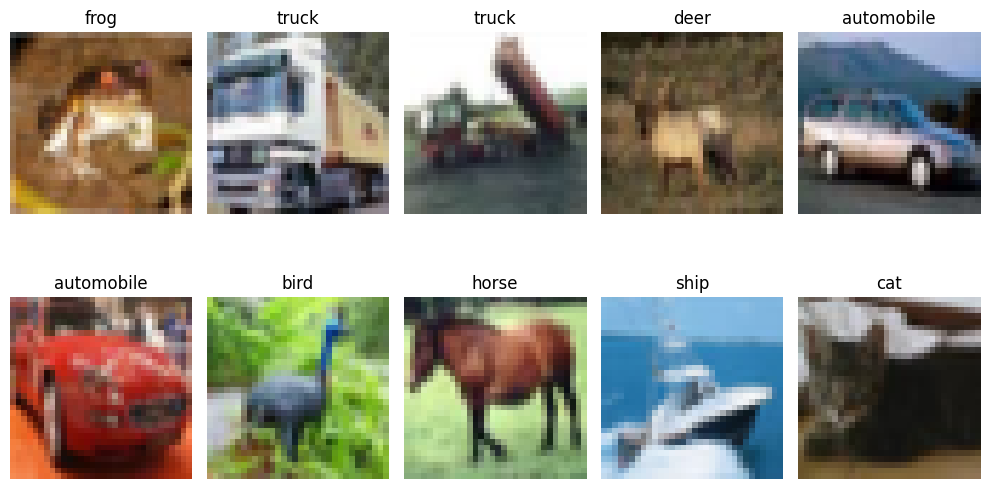

In [9]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
print(f"Running Part B - CNN Model Implementation")
print(f"Roll No: {ROLL_NO}\n")

Running Part B - CNN Model Implementation
Roll No: 24BAD046



In [10]:
model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # Max Pooling Layer 1
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling Layer 2
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [36]:
print(f"Running Part C - Model Training and Evaluation")
print(f"Roll No: {ROLL_NO}\n")

Running Part C - Model Training and Evaluation
Roll No: 24BAD046



In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 98ms/step - accuracy: 0.4482 - loss: 1.5193 - val_accuracy: 0.5688 - val_loss: 1.2126
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.5903 - loss: 1.1559 - val_accuracy: 0.6332 - val_loss: 1.0472
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.6489 - loss: 0.9935 - val_accuracy: 0.6604 - val_loss: 0.9777
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.6896 - loss: 0.8822 - val_accuracy: 0.6884 - val_loss: 0.8960
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.7230 - loss: 0.7927 - val_accuracy: 0.6986 - val_loss: 0.8664
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.7465 - loss: 0.7226 - val_accuracy: 0.7130 - val_loss: 0.8381
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.7715 - loss: 0.6562 - val_accuracy: 0.7276 - val_loss: 0.8181
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.7929 - loss: 0.5953 - 

In [14]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.9214147329330444
Test Accuracy: 0.7041000127792358


In [15]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Testing Accuracy:",
      test_accuracy)

Final Training Accuracy: 0.8285999894142151
Final Validation Accuracy: 0.72079998254776
Testing Accuracy: 0.7041000127792358


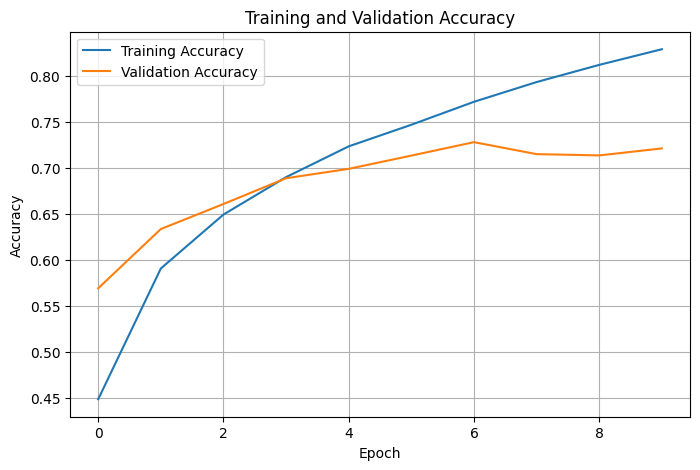

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

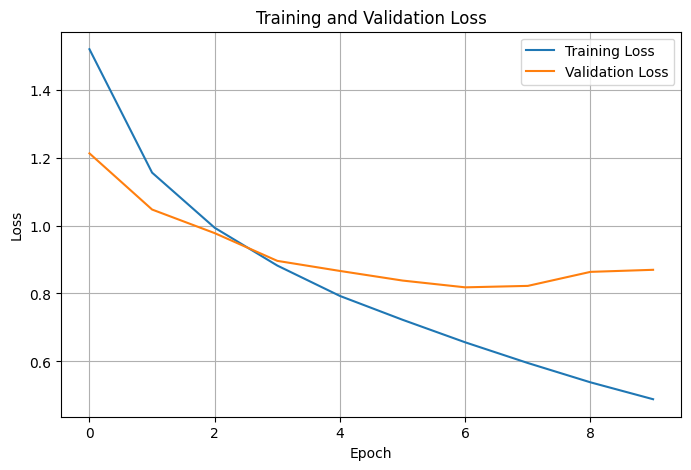

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [37]:
print(f"Running Part D - Performance Analysis")
print(f"Roll No: {ROLL_NO}\n")

Running Part D - Performance Analysis
Roll No: 24BAD046



In [18]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

print("Predictions generated successfully")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions generated successfully


In [19]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.76      0.69      0.72      1000
  automobile       0.87      0.77      0.82      1000
        bird       0.68      0.51      0.58      1000
         cat       0.55      0.49      0.52      1000
        deer       0.59      0.76      0.66      1000
         dog       0.57      0.68      0.62      1000
        frog       0.70      0.84      0.77      1000
       horse       0.77      0.75      0.76      1000
        ship       0.83      0.78      0.81      1000
       truck       0.79      0.78      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



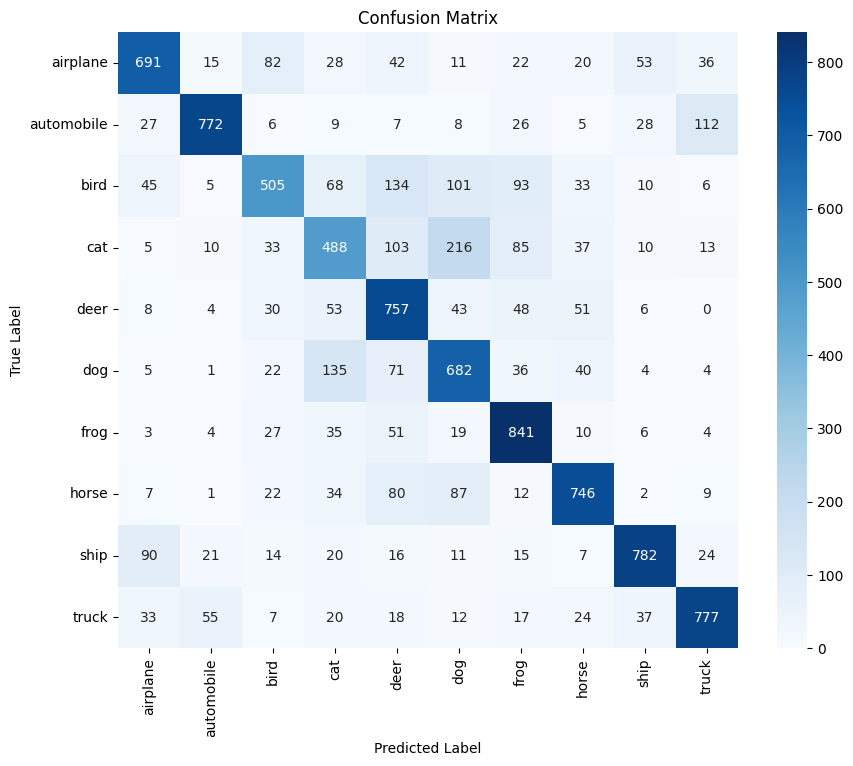

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

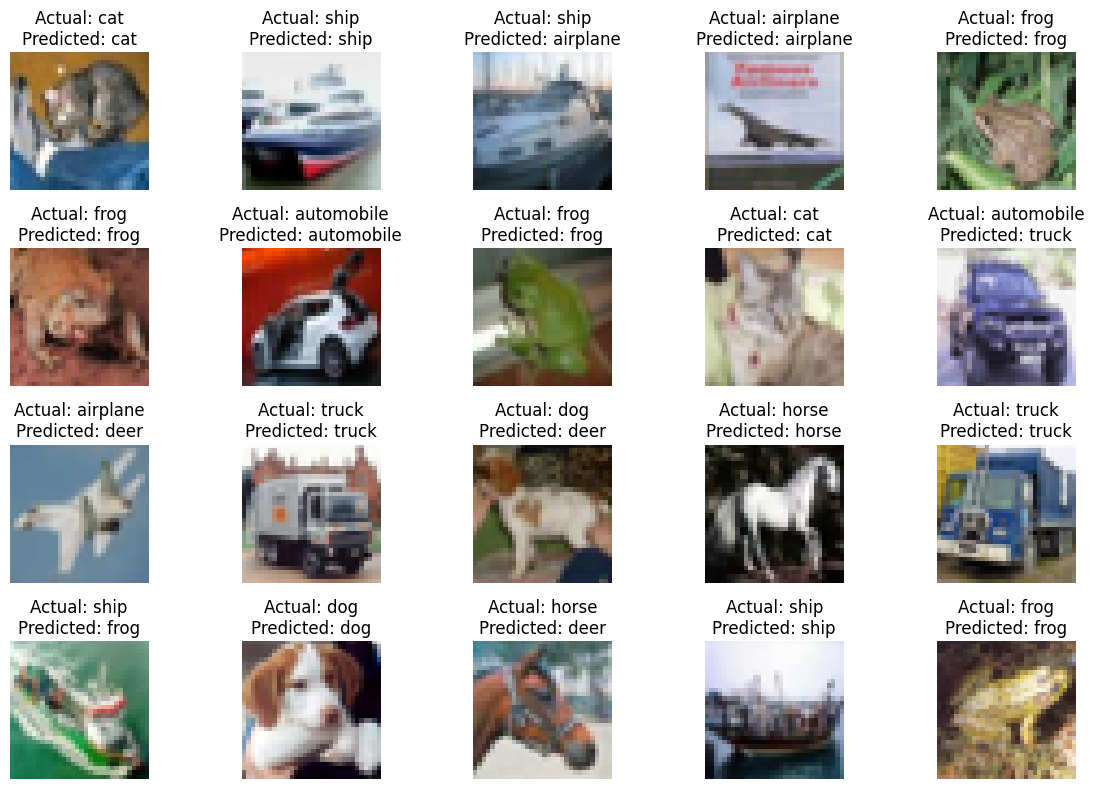

In [21]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[i])

    predicted = class_names[y_pred_classes[i]]
    actual = class_names[y_true[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
misclassified = np.where(
    y_pred_classes != y_true
)[0]

print("Number of misclassified images:",
      len(misclassified))

Number of misclassified images: 2959


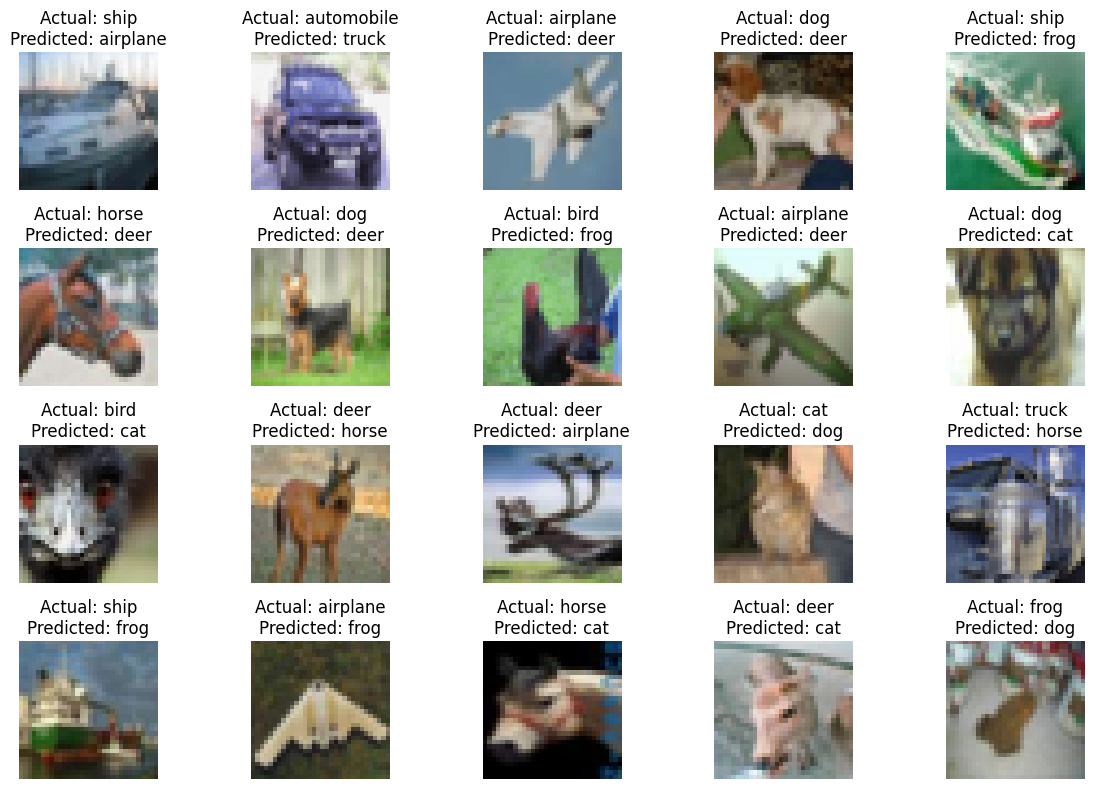

In [23]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(misclassified[:20]):

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred_classes[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()